In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

X = np.random.randint(800, 5001, 100)
e = np.random.normal(0, 50000, 100)
y = 150 * X + e


In [4]:
df = pd.DataFrame({'SqFt': X, 'Price': y})


In [5]:
nan_indices = np.random.choice(df.index, 5, replace=False)
df.loc[nan_indices, 'Price'] = np.nan
df['Price'].fillna(df['Price'].median(), inplace=True)


/var/folders/wb/r3mr__493xx01mrr2cl59x8h0000gn/T/ipykernel_34646/51487256.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Price'].fillna(df['Price'].median(), inplace=True)


0     338714.042150
1     714834.477087
2     598682.522425
3     138494.211471
4     436061.330737
          ...      
95     96202.979547
96    198627.155326
97    209291.116749
98    538257.152767
99    185283.834687
Name: Price, Length: 100, dtype: float64

In [6]:
locations = np.random.choice(['Urban', 'Suburban', 'Rural'], 100)
df['Location'] = locations

In [7]:
df = pd.get_dummies(df, columns=['Location'])


In [8]:
corr_matrix = df.corr()


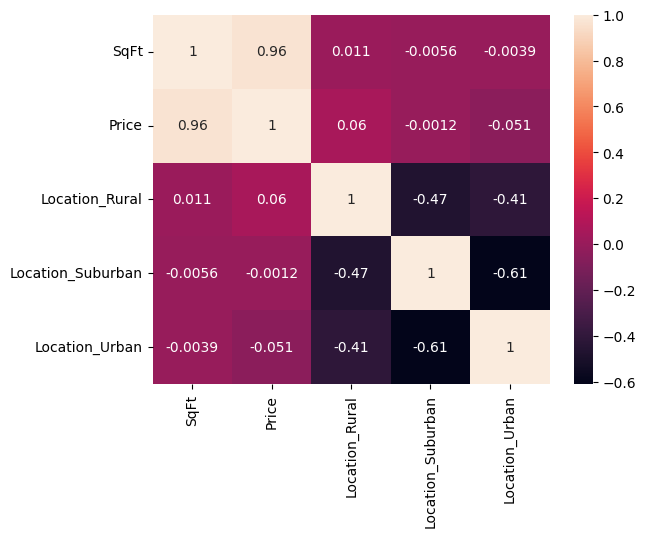

In [9]:
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.show()

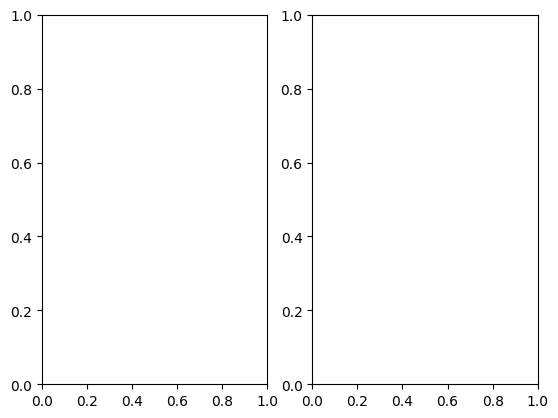

In [10]:
fig, axes = plt.subplots(1, 2)


In [11]:
axes[0].hist(df['Price'])
axes[0].set_title('Price Histogram')


Text(0.5, 1.0, 'Price Histogram')

In [13]:
axes[1].scatter(df['SqFt'], df['Price'])
axes[1].set_title('SqFt vs Price')

Text(0.5, 1.0, 'SqFt vs Price')

In [14]:
plt.show()